# London Airbnb Market Research
### Pricing, host concentration, and commercial listings across 33 boroughs

**Dataset:** Inside Airbnb London listings export (Kaggle), 69,351 listings
**Author:** [Your Name] · **Date:** [Report Date]


In [1]:
import sys
sys.path.insert(0, '../src')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from metrics import (
    robust_price_stats, host_concentration_index,
    commercial_listing_summary, demand_supply_view
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

DB_PATH = '../data/database/airbnb.db'
conn = sqlite3.connect(DB_PATH)


## 1. Load cleaned data
Raw CSV had two fully-null columns (`neighbourhood_group`, `license`), 19 zero-price listings, and heavy price outliers - all handled in `src/clean_data.py`. Loading the cleaned data from the database here.

In [2]:
listings = pd.read_sql('SELECT * FROM listings', conn, parse_dates=['last_review'])
hosts = pd.read_sql('SELECT * FROM hosts', conn)

print(f'{len(listings):,} listings across {listings["neighbourhood"].nunique()} boroughs')
print(f'{listings["host_id"].nunique():,} unique hosts')
listings.head()


69,351 listings across 33 boroughs
45,229 unique hosts


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,price_capped,is_zero_price,is_price_outlier,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,availability_tier,number_of_reviews_ltm,has_reviews,days_since_last_review,host_tier,likely_commercial
0,13913,Holiday London DB Room Let-on going,54730,Alina,Islington,51.56861,-0.11270,Private room,50.0,50.0,0,0,1,30,2022-07-15,0.20,2,343,Very high (271-365d),9,1,78.0,2 listings,0
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,Kensington and Chelsea,51.48780,-0.16813,Entire home/apt,75.0,75.0,0,0,3,89,2020-03-16,0.57,1,70,Low (1-90d),0,1,929.0,Single listing,0
2,17402,Superb 3-Bed/2 Bath & Wifi: Trendy W1,67564,Liz,Westminster,51.52195,-0.14094,Entire home/apt,379.0,379.0,0,0,4,51,2022-09-06,0.36,5,249,High (181-270d),8,1,25.0,3-5 listings,0
3,24328,"Battersea live/work artist house, garden communal",41759,Joe,Wandsworth,51.47072,-0.16266,Entire home/apt,195.0,195.0,0,0,3,96,2022-07-19,0.67,1,116,Moderate (91-180d),3,1,74.0,Single listing,0
4,25123,Clean big Room in London (Room 1),103583,Grace,Barnet,51.57438,-0.21081,Private room,29.0,29.0,0,0,10,129,2020-03-15,0.85,3,0,Never available,0,1,930.0,3-5 listings,0


## 2. Data quality at a glance

In [3]:
print('Zero-price listings (data errors, excluded from price stats):', listings['is_zero_price'].sum())
print('Price outliers (>99th percentile, flagged not dropped):', listings['is_price_outlier'].sum())
print('Listings with no reviews yet:', (~listings['has_reviews'].astype(bool)).sum(),
      f"({(~listings['has_reviews'].astype(bool)).mean()*100:.1f}%)")


Zero-price listings (data errors, excluded from price stats): 19
Price outliers (>99th percentile, flagged not dropped): 481
Listings with no reviews yet: 16780 (24.2%)


## 3. Pricing by borough
Price is heavily right-skewed, so **median** (not mean) is used throughout.

In [4]:
price_stats = robust_price_stats(listings, 'neighbourhood')
price_stats.head(10)


,neighbourhood,n_listings,median_price,mean_price,p25_price,p75_price,std_price
0,City of London,421,196.0,237.62,130.00,279.00,168.95
1,Kensington and Chelsea,4532,182.0,257.55,114.75,300.25,239.85
2,Westminster,7659,176.0,258.73,100.00,320.00,251.27
3,Camden,4678,124.0,170.50,76.00,200.00,168.26
4,Hammersmith and Fulham,2968,110.0,161.55,65.00,186.25,178.23
5,Richmond upon Thames,1099,100.0,142.70,65.00,170.50,139.85
6,Islington,3762,99.0,131.72,60.00,150.00,140.85
7,Wandsworth,3442,99.0,142.89,60.00,170.00,153.35
8,Southwark,3951,95.0,187.33,55.00,165.00,318.54
9,Hackney,5153,86.0,115.98,50.00,140.00,117.53


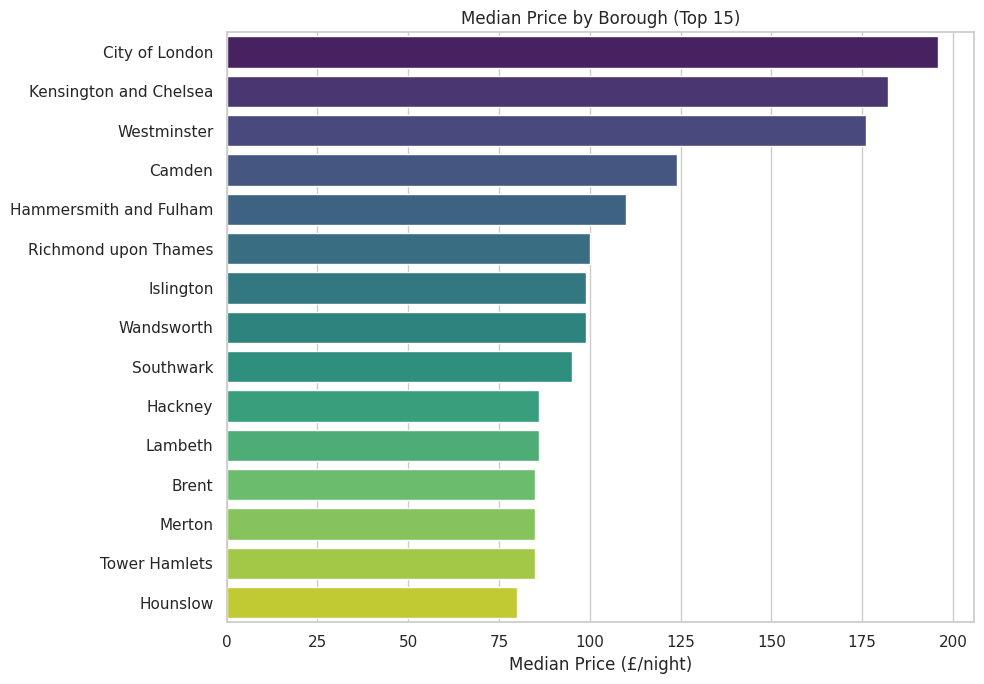

In [5]:
top15 = price_stats.head(15)
fig, ax = plt.subplots(figsize=(10,7))
sns.barplot(data=top15, y='neighbourhood', x='median_price', hue='neighbourhood', palette='viridis', legend=False, ax=ax)
ax.set_title('Median Price by Borough (Top 15)')
ax.set_xlabel('Median Price (£/night)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 4. Room type mix
Entire homes cost more than private/shared rooms, as expected - the question is by how much.

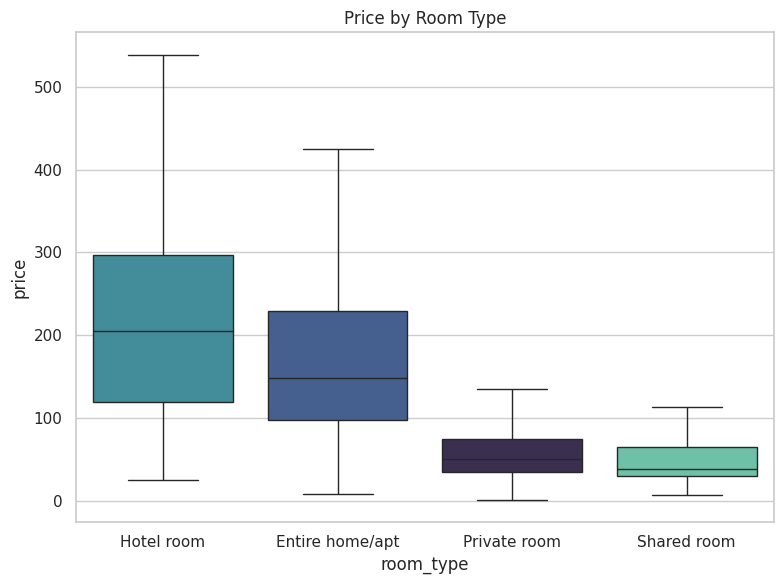

room_type
Hotel room         205.0
Entire home/apt    148.0
Private room        50.0
Shared room         39.0
Name: price, dtype: float64

In [6]:
clean = listings[listings['is_price_outlier']==0]
fig, ax = plt.subplots(figsize=(8,6))
order = clean.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=clean, x='room_type', y='price', order=order, hue='room_type', palette='mako', legend=False, showfliers=False, ax=ax)
ax.set_title('Price by Room Type')
plt.tight_layout()
plt.show()

clean.groupby('room_type')['price'].median().sort_values(ascending=False)


## 5. Host concentration
Using the Herfindahl-Hirschman Index (HHI), a standard concentration metric from antitrust analysis, to see how much of the market sits with a few hosts vs. many.

In [7]:
concentration = host_concentration_index(listings)
concentration


{'hhi': np.float64(1.73),
 'top_10_hosts_share_pct': np.float64(2.73),
 'multi_listing_host_share_pct': np.float64(45.92),
 'n_unique_hosts': 45229,
 'n_listings': 69351}

An HHI this low means no single host dominates. But `multi_listing_host_share_pct` tells a
different story - it's the share of *all listings* owned by hosts with more than one property,
which is the better lens on how "professionalized" the platform actually is.

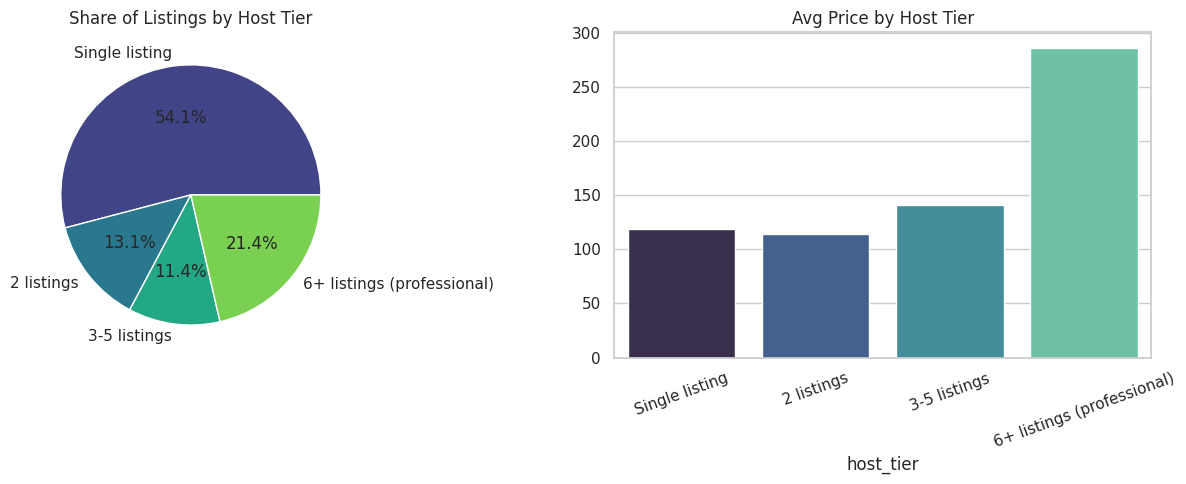

In [8]:
tier_counts = listings['host_tier'].value_counts()
order = ['Single listing', '2 listings', '3-5 listings', '6+ listings (professional)']
tier_counts = tier_counts.reindex(order)

tier_avg_price = clean.groupby('host_tier')['price'].mean().reindex(order)

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis',4))
axes[0].set_title('Share of Listings by Host Tier')
sns.barplot(x=tier_avg_price.index, y=tier_avg_price.values, hue=tier_avg_price.index, palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Avg Price by Host Tier')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 6. Likely-commercial listings
A listing is flagged *likely commercial* if it's an entire home/apt, the host runs 2+ listings, and it's available 270+ days/year. It's a heuristic, not a legal determination - just a way to approximate managed-rental activity vs. genuine home-sharing.

In [9]:
commercial = commercial_listing_summary(listings)
commercial.head(10)


,neighbourhood,total_listings,commercial_listings,pct_commercial
0,City of London,424,122,28.77
1,Westminster,7763,1179,15.19
2,Harrow,444,66,14.86
3,Hillingdon,714,92,12.89
4,Kensington and Chelsea,4612,566,12.27
5,Hounslow,1078,130,12.06
6,Havering,329,39,11.85
7,Bexley,411,47,11.44
8,Barnet,1611,179,11.11
9,Camden,4707,508,10.79


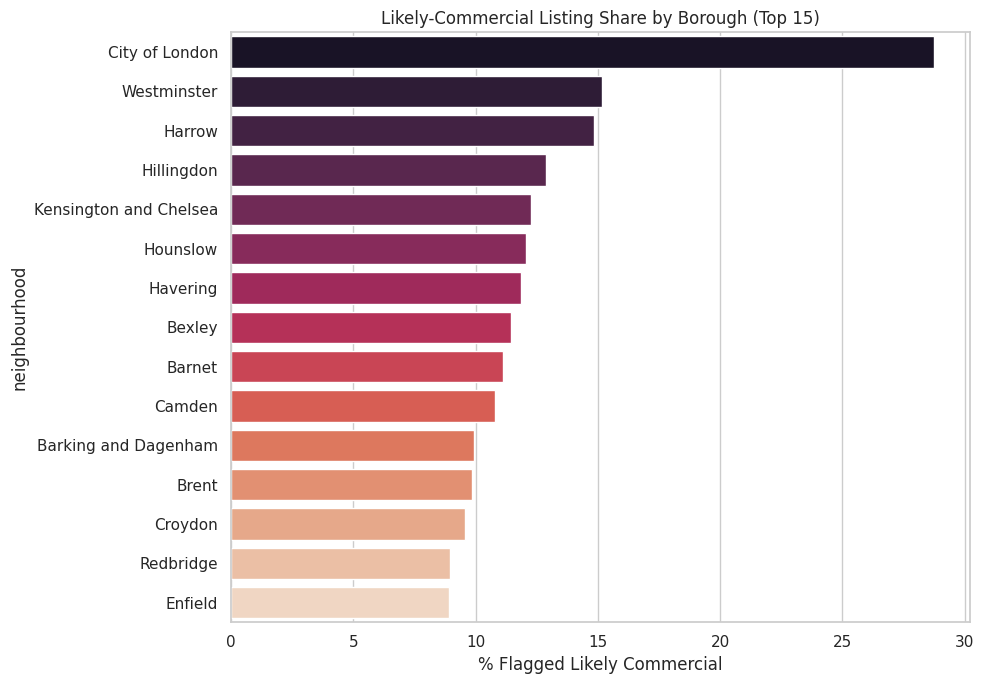

In [10]:
top15_commercial = commercial.head(15)
fig, ax = plt.subplots(figsize=(10,7))
sns.barplot(data=top15_commercial, y='neighbourhood', x='pct_commercial', hue='neighbourhood', palette='rocket', legend=False, ax=ax)
ax.set_title('Likely-Commercial Listing Share by Borough (Top 15)')
ax.set_xlabel('% Flagged Likely Commercial')
plt.tight_layout()
plt.show()


## 7. Demand vs. price
No real booking data exists in this export, so `reviews_per_month` stands in for demand - more completed stays roughly means more reviews.

In [11]:
demand = demand_supply_view(listings)
demand.head(10)


,neighbourhood,n_listings,avg_reviews_per_month,avg_price,pct_with_reviews
0,City of London,421,1.02,237.62,76.2
1,Hillingdon,714,0.90,98.27,77.9
2,Westminster,7659,0.86,258.73,75.3
3,Camden,4678,0.85,170.50,79.0
4,Kingston upon Thames,580,0.73,115.83,78.4
5,Brent,2064,0.73,198.70,73.6
6,Richmond upon Thames,1099,0.71,142.70,79.1
7,Bexley,411,0.70,89.69,71.8
8,Hounslow,1074,0.69,153.28,74.3
9,Croydon,1066,0.69,82.56,76.2


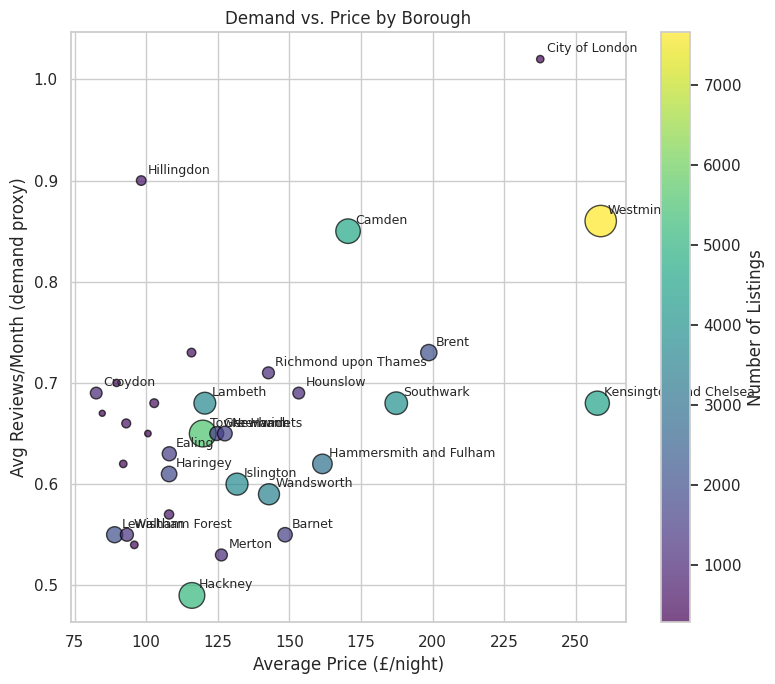

In [12]:
fig, ax = plt.subplots(figsize=(8,7))
sc = ax.scatter(demand['avg_price'], demand['avg_reviews_per_month'], s=demand['n_listings']/15,
                 c=demand['n_listings'], cmap='viridis', alpha=0.7, edgecolor='black')
for _, row in demand.iterrows():
    if row['n_listings'] > 1000 or row['avg_reviews_per_month'] > 0.85:
        ax.annotate(row['neighbourhood'], (row['avg_price'], row['avg_reviews_per_month']), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.colorbar(sc, label='Number of Listings')
ax.set_xlabel('Average Price (£/night)')
ax.set_ylabel('Avg Reviews/Month (demand proxy)')
ax.set_title('Demand vs. Price by Borough')
plt.tight_layout()
plt.show()


## 8. Key findings

1. **Central boroughs command a clear price premium.** City of London, Kensington & Chelsea, and Westminster top the median-price ranking, consistent with prime location value.
2. **The market is meaningfully "professionalized."** Roughly 46% of listings belong to hosts with more than one listing, and hosts with 6+ listings charge nearly 2.4x the average price of single-listing hosts.
3. **Likely-commercial listings cluster in specific boroughs**, led by City of London (~29%) and Westminster (~15%) — both dense, high-tourist-traffic areas where short-let regulation debates are most active.
4. **Demand (reviews/month) doesn't map one-to-one with price** — some lower-priced outer boroughs post above-average review activity relative to their listing volume, suggesting under-served or highly efficient markets worth a closer look.

## 9. Recommendation / Next Steps

For a host-facing product or a market-entry analysis, the data suggests: (a) central boroughs support premium pricing but face the most competitive, professionalized supply; (b) several outer boroughs show a favorable demand-to-price ratio and lower professionalization, which may represent an easier entry point for new hosts; (c) any policy or platform-integrity analysis should treat `likely_commercial` boroughs (esp. City of London, Westminster) as the priority segment for further investigation, since our heuristic can only approximate — not confirm — commercial-use classification.

---
*See `reports/research_report.md` for the full written report and `dashboard/app.py` for an interactive version of this analysis.*
